# 4. Apriori Association Rules Model ✅

Market basket analysis to discover co-purchase patterns.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline
sns.set_style('whitegrid')

import sys
import sys
import os

sys.path.append(os.path.abspath('../src'))
from apriori_model import (
    create_transaction_matrix,
    fit_apriori_model,
    analyze_rules_quality
)
import joblib

In [6]:
# Load cleaned data from preprocessing
cleaned = pd.read_csv('data/processed/cleaned_user_products.csv')
print(f'Loaded cleaned data: {cleaned.shape}')
print('\nUnique orders:', cleaned['order_id'].nunique())
print('\nUnique products:', cleaned['product_name'].nunique())
print('\nSample orders:')
print(cleaned.groupby('order_id')['product_name'].apply(list).head())

Loaded cleaned data: (17515025, 6)

Unique orders: 2963012

Unique products: 1000

Sample orders:
order_id
2    [Organic Egg Whites, Michigan Organic Kale, Ga...
3    [Total 2% with Strawberry Lowfat Greek Straine...
4    [Plain Pre-Sliced Bagels, Goldfish Cheddar Bak...
5    [Bag of Organic Bananas, Organic Raspberries, ...
7                     [Orange Juice, Pineapple Chunks]
Name: product_name, dtype: object


In [7]:
# Create transaction data
transactions = create_transaction_matrix(cleaned)
print(f'\n✅ Created {len(transactions)} transactions')

Creating transaction matrix...
Created 50000 baskets

✅ Created 50000 transactions


In [8]:
# Fit Apriori model (tune parameters for your data size)
print('🚀 Running Apriori... (few minutes)')
rules = fit_apriori_model(
    transactions, 
    min_support=0.003,   # Adjust based on data size
    min_confidence=0.1
)

print(f'\n🎉 Generated {len(rules)} high-quality rules!')
print('\nTop 5 rules by lift:')
print(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head())

🚀 Running Apriori... (few minutes)
Basket DataFrame shape: (50000, 1000)


e:\Ecommerce Recommendation System\.venv\Lib\site-packages\mlxtend\frequent_patterns\fpcommon.py:175: DeprecationWarning: DataFrames with non-bool types result in worse computationalperformance and their support might be discontinued in the future.Please use a DataFrame with bool type
  warnings.warn(


Found 891 frequent itemsets
✅ Saved 353 rules to models/apriori_rules.joblib

🎉 Generated 353 high-quality rules!

Top 5 rules by lift:
                                           antecedents  \
334  frozenset({Total 2% Lowfat Greek Strained Yogu...   
333  frozenset({Total 2% with Strawberry Lowfat Gre...   
195                  frozenset({Lime Sparkling Water})   
194            frozenset({Sparkling Water Grapefruit})   
279                        frozenset({Organic Garlic})   

                                           consequents  support  confidence  \
334  frozenset({Total 2% with Strawberry Lowfat Gre...  0.00300    0.426136   
333  frozenset({Total 2% Lowfat Greek Strained Yogu...  0.00300    0.296443   
195            frozenset({Sparkling Water Grapefruit})  0.00398    0.259115   
194                  frozenset({Lime Sparkling Water})  0.00398    0.165695   
279                   frozenset({Organic Ginger Root})  0.00394    0.108780   

          lift  
334  42.108336  
333  4

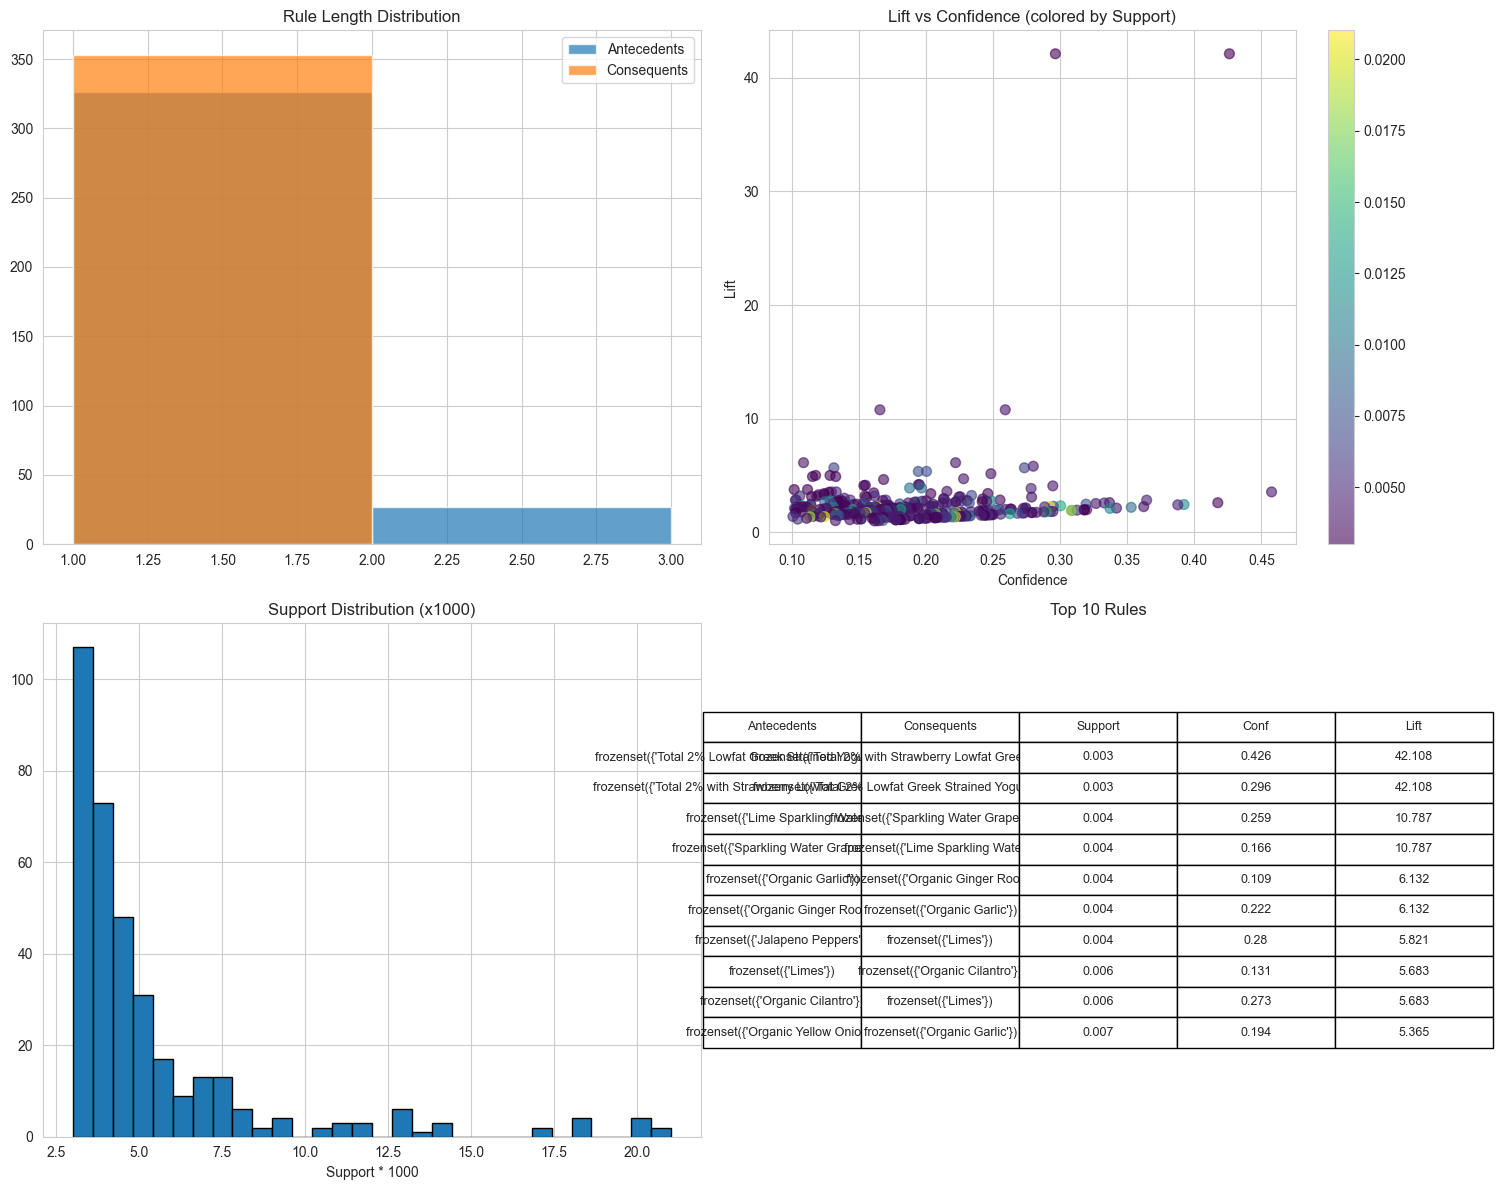


Rule Statistics:
       support  confidence     lift
count  353.000     353.000  353.000
mean     0.005       0.193    2.477
std      0.003       0.062    3.198
min      0.003       0.101    1.010
25%      0.003       0.149    1.598
50%      0.004       0.181    2.020
75%      0.006       0.226    2.565
max      0.021       0.458   42.108


In [9]:
# Rule quality analysis
analyze_rules_quality(rules)

# Rule statistics
print('\nRule Statistics:')
print(rules[['support', 'confidence', 'lift']].describe().round(3))

In [13]:
# TOP RECOMMENDATION RULES
print('🏆 Top 15 Rules by Lift:')
top_rules = rules.nlargest(15, 'lift')[['antecedents', 'consequents', 'confidence', 'lift']]
for idx, row in top_rules.iterrows():
    ante = ', '.join(list(row['antecedents']))
    cons = ', '.join(list(row['consequents']))
    print(f"{ante} → {cons} (conf={row['confidence']:.1%}, lift={row['lift']:.2f})")

🏆 Top 15 Rules by Lift:
Total 2% Lowfat Greek Strained Yogurt With Blueberry → Total 2% with Strawberry Lowfat Greek Strained Yogurt (conf=42.6%, lift=42.11)
Total 2% with Strawberry Lowfat Greek Strained Yogurt → Total 2% Lowfat Greek Strained Yogurt With Blueberry (conf=29.6%, lift=42.11)
Lime Sparkling Water → Sparkling Water Grapefruit (conf=25.9%, lift=10.79)
Sparkling Water Grapefruit → Lime Sparkling Water (conf=16.6%, lift=10.79)
Organic Garlic → Organic Ginger Root (conf=10.9%, lift=6.13)
Organic Ginger Root → Organic Garlic (conf=22.2%, lift=6.13)
Jalapeno Peppers → Limes (conf=28.0%, lift=5.82)
Limes → Organic Cilantro (conf=13.1%, lift=5.68)
Organic Cilantro → Limes (conf=27.3%, lift=5.68)
Organic Yellow Onion → Organic Garlic (conf=19.4%, lift=5.37)
Organic Garlic → Organic Yellow Onion (conf=20.0%, lift=5.37)
Bunched Cilantro → Limes (conf=24.8%, lift=5.16)
Organic Small Bunch Celery → Carrots (conf=12.9%, lift=5.01)
Carrots → Organic Small Bunch Celery (conf=11.8%, lift=

In [14]:
# Save rules with product details
rules.to_pickle('data/processed/apriori_rules.pkl')
print('✅ Rules saved to data/processed/apriori_rules.pkl')

# Quick test recommendation
rules_loaded = joblib.load('models/apriori_rules.joblib')
print('\nModel loaded successfully! Ready for hybrid recommender.')

✅ Rules saved to data/processed/apriori_rules.pkl

Model loaded successfully! Ready for hybrid recommender.


## Phase 4 Summary ✅

**Generated:**
- `models/apriori_rules.joblib` - Association rules model
- `results/rules_analysis.png` - Rule quality visualization
- `data/processed/apriori_rules.pkl` - Rules with metadata

**Ready for Hybrid Recommender (Notebook 5)!** 🛒